# ДЗ2. DEER на CoNLL-2003

In-context NER с выбором демонстраций по меткам, сравниваю с zero-shot, random и KATE на одной модели.

## Конфиг

In [2]:
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv(usecwd=True))
API_KEY = os.environ["OPENROUTER_API_KEY"]
BASE_URL = "https://openrouter.ai/api/v1"
MODEL = "qwen/qwen-2.5-72b-instruct"
EMB_ID = "sentence-transformers/all-MiniLM-L6-v2"

ENTITY_TYPES = ["PER", "ORG", "LOC", "MISC"]
N_SHOTS = 8
N_TEST = 200
WINDOW = 2
L1, L2 = 1.0, 1.0
WE, WC, WO = 1.0, 1.0, 0.01
SEED = 42

print("Model:", MODEL)

Model: qwen/qwen-2.5-72b-instruct


In [3]:
# !pip install -q openai python-dotenv sentence-transformers seqeval datasets

In [4]:
import re
import json
import random
from collections import defaultdict

import numpy as np
from tqdm import tqdm

## CoNLL-2003

4 типа сущностей: PER, ORG, LOC, MISC

In [5]:
from datasets import load_dataset


def bio_to_entities(tokens, tags):
    ents, i, n = [], 0, len(tokens)
    while i < n:
        if tags[i].startswith("B-"):
            typ = tags[i][2:]
            j = i + 1
            while j < n and tags[j] == f"I-{typ}":
                j += 1
            ents.append({"name": " ".join(tokens[i:j]), "type": typ, "token_idx": [i, j - 1]})
            i = j
        else:
            i += 1
    return ents


def entities_to_bio(tokens, ent_list):
    tags = ["O"] * len(tokens)
    for e in ent_list:
        s, t = e["token_idx"]
        if 0 <= s <= t < len(tokens):
            tags[s] = f"B-{e['type']}"
            for i in range(s + 1, t + 1):
                tags[i] = f"I-{e['type']}"
    return tags


raw = load_dataset("eriktks/conll2003", revision="convert/parquet")
label_names = raw["train"].features["ner_tags"].feature.names


def to_example(row):
    tokens = row["tokens"]
    tags = [label_names[i] for i in row["ner_tags"]]
    return {"tokens": tokens, "ent_list": bio_to_entities(tokens, tags), "text": " ".join(tokens)}


train_examples = [to_example(r) for r in raw["train"]]
test_all = [to_example(r) for r in raw["test"]]
test_examples = [test_all[i] for i in random.Random(SEED).sample(range(len(test_all)), N_TEST)]

print(f"train: {len(train_examples)}  test (eval): {len(test_examples)}")

train: 14041  test (eval): 200


## DEER
В отличие от чисто семантической близости KATE выбираю демо с учётом меток трейна. По трейну для каждого токена считаю, как часто он бывает сущностью, контекстом сущности в окне +-2 или прочим, отсюда вес токена `W = w_e·P_e + w_c·P_c + w_o·P_o` с весами 1.0 / 1.0 / 0.01.

Близость демо к запросу `L1·S_token + L2·S_embed`: `S_token` это взвешенное метками совпадение токенов, `S_embed` cos SBERT. без Error-reflection из статьи

In [6]:
def classify_tokens(tokens, ent_list, window=WINDOW):
    n = len(tokens)
    ent_pos = set()
    for e in ent_list:
        ent_pos.update(range(e["token_idx"][0], e["token_idx"][1] + 1))
    cls = ["other"] * n
    for i in ent_pos:
        cls[i] = "entity"
    for i in ent_pos:
        for j in range(max(0, i - window), min(n, i + window + 1)):
            if j not in ent_pos:
                cls[j] = "context"
    return cls


def compute_token_stats(train):
    counts = defaultdict(lambda: [0, 0, 0])
    order = {"entity": 0, "context": 1, "other": 2}
    for ex in train:
        for tok, c in zip(ex["tokens"], classify_tokens(ex["tokens"], ex["ent_list"])):
            counts[tok.lower()][order[c]] += 1
    stats = {}
    for tok, (e, c, o) in counts.items():
        total = e + c + o
        pe, pc, po = e / total, c / total, o / total
        stats[tok] = {"Pe": pe, "Pc": pc, "Po": po, "W": WE * pe + WC * pc + WO * po}
    return stats


token_stats = compute_token_stats(train_examples)

for tok in ["london", "the", "minister", "1996"]:
    s = token_stats.get(tok)
    if s:
        print(f"{tok:<10} Pe={s['Pe']:.2f} Pc={s['Pc']:.2f} Po={s['Po']:.2f} W={s['W']:.2f}")

london     Pe=1.00 Pc=0.00 Po=0.00 W=1.00
the        Pe=0.01 Pc=0.31 Po=0.68 W=0.33
minister   Pe=0.00 Pc=0.80 Po=0.20 W=0.80
1996       Pe=0.01 Pc=0.09 Po=0.90 W=0.11


## Модель и retrieval

In [7]:
from openai import OpenAI
from sentence_transformers import SentenceTransformer

client = OpenAI(base_url=BASE_URL, api_key=API_KEY)

sbert = SentenceTransformer(EMB_ID, device="cpu")
train_embs = sbert.encode([ex["text"] for ex in train_examples], convert_to_numpy=True,
                          normalize_embeddings=True, batch_size=128)
test_embs = sbert.encode([ex["text"] for ex in test_examples], convert_to_numpy=True,
                         normalize_embeddings=True, batch_size=128)

token_to_train = defaultdict(list)
for idx, ex in enumerate(train_examples):
    for t in set(tok.lower() for tok in ex["tokens"]):
        token_to_train[t].append(idx)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [8]:
def s_token_scores(q_tokens):
    scores = np.zeros(len(train_examples))
    for t in set(tok.lower() for tok in q_tokens):
        w = token_stats.get(t, {}).get("W", 1.0)
        for idx in token_to_train.get(t, ()):
            scores[idx] += w
    return scores


def retrieve(query, q_emb, method, n=N_SHOTS):
    if method == "zero" or n == 0:
        return []
    if method == "random":
        idxs = random.Random(SEED + len(query["tokens"])).sample(range(len(train_examples)), n)
    else:
        s_embed = train_embs @ q_emb
        score = s_embed if method == "kate" else L1 * s_token_scores(query["tokens"]) + L2 * s_embed
        idxs = np.argsort(score)[-n:].tolist()
    return [train_examples[i] for i in idxs]

## Промпт, генерация, парсинг

In [9]:
import time

SYSTEM = (
    "You are a named entity recognition system. "
    "Extract all named entities of these types: PER, ORG, LOC, MISC. "
    'Respond with ONLY a JSON object: {"named_entities": [{"name": "...", "type": "..."}]}. '
    "Use an empty list if there are no entities."
)

TYPE_MAP = {"PERSON": "PER", "LOCATION": "LOC", "ORGANIZATION": "ORG", "MISCELLANEOUS": "MISC"}


def build_messages(demos, query_text):
    msgs = [{"role": "system", "content": SYSTEM}]
    for d in demos:
        gold = {"named_entities": [{"name": e["name"], "type": e["type"]} for e in d["ent_list"]]}
        msgs.append({"role": "user", "content": f"Input: {d['text']}"})
        msgs.append({"role": "assistant", "content": json.dumps(gold)})
    msgs.append({"role": "user", "content": f"Input: {query_text}"})
    return msgs


def generate(messages):
    for attempt in range(3):
        try:
            resp = client.chat.completions.create(model=MODEL, messages=messages, temperature=0, max_tokens=256)
            return resp.choices[0].message.content or ""
        except Exception as e:
            if attempt == 2:
                print("generate failed:", e)
                return ""
            time.sleep(2)


def parse_entities(text):
    m = re.search(r"\{.*\}", text, re.DOTALL)
    if not m:
        return []
    try:
        data = json.loads(m.group())
    except json.JSONDecodeError:
        return []
    return [{"name": e.get("name", ""), "type": e.get("type", "")}
            for e in data.get("named_entities", []) if isinstance(e, dict)]


def entities_to_offsets(pred, tokens):
    lower = [t.lower() for t in tokens]
    used = [False] * len(tokens)
    out = []
    for e in pred:
        name = e.get("name", "").strip()
        typ = TYPE_MAP.get(e.get("type", "").upper(), e.get("type", ""))
        if not name or typ not in ENTITY_TYPES:
            continue
        words = name.lower().split()
        for s in range(len(tokens) - len(words) + 1):
            if not any(used[s:s + len(words)]) and lower[s:s + len(words)] == words:
                for i in range(s, s + len(words)):
                    used[i] = True
                out.append({"name": name, "type": typ, "token_idx": [s, s + len(words) - 1]})
                break
    return out


txt = generate(build_messages(retrieve(test_examples[0], test_embs[0], "deer"), test_examples[0]["text"]))
print(test_examples[0]["text"])
print(txt)
print(parse_entities(txt))

( 52.76 / 53.18 )
{"named_entities": []}
[]


## Запуск, оценка

In [10]:
from seqeval.metrics import f1_score, precision_score, recall_score
from seqeval.scheme import IOB2


def run_config(method):
    gold, pred, raw_txt = [], [], []
    for qi, ex in enumerate(tqdm(test_examples, desc=method)):
        demos = retrieve(ex, test_embs[qi], method)
        txt = generate(build_messages(demos, ex["text"]))
        ents = entities_to_offsets(parse_entities(txt), ex["tokens"])
        gold.append(entities_to_bio(ex["tokens"], ex["ent_list"]))
        pred.append(entities_to_bio(ex["tokens"], ents))
        raw_txt.append(txt)
    return gold, pred, raw_txt


def score(gold, pred):
    kw = dict(mode="strict", scheme=IOB2)
    return {"precision": precision_score(gold, pred, **kw),
            "recall": recall_score(gold, pred, **kw),
            "f1": f1_score(gold, pred, **kw)}


outputs, results = {}, {}
for method in ["zero", "random", "kate", "deer"]:
    g, p, r = run_config(method)
    outputs[method] = (g, p, r)
    results[method] = score(g, p)
    print(method, {k: round(v, 3) for k, v in results[method].items()})

zero: 100%|██████████| 200/200 [07:52<00:00,  2.36s/it]


zero {'precision': np.float64(0.693), 'recall': np.float64(0.729), 'f1': np.float64(0.71)}


random: 100%|██████████| 200/200 [05:16<00:00,  1.58s/it]


random {'precision': np.float64(0.766), 'recall': np.float64(0.787), 'f1': np.float64(0.776)}


kate: 100%|██████████| 200/200 [05:17<00:00,  1.59s/it]


kate {'precision': np.float64(0.881), 'recall': np.float64(0.89), 'f1': np.float64(0.885)}


deer: 100%|██████████| 200/200 [07:01<00:00,  2.11s/it]

deer {'precision': np.float64(0.897), 'recall': np.float64(0.9), 'f1': np.float64(0.899)}


## Результаты

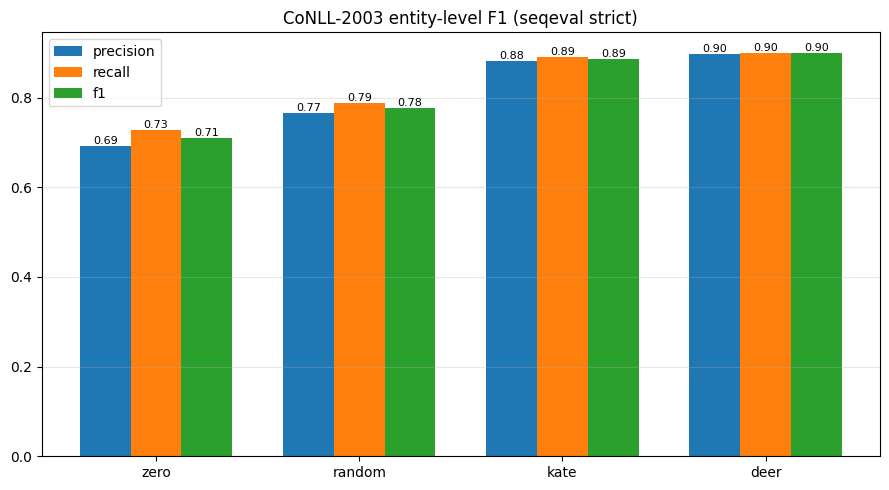

In [11]:
import matplotlib.pyplot as plt

labels = list(results)
metrics = ["precision", "recall", "f1"]
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9, 5))
for i, m in enumerate(metrics):
    vals = [results[c][m] for c in labels]
    ax.bar(x + (i - 1) * 0.25, vals, 0.25, label=m)
    for j, v in enumerate(vals):
        ax.text(x[j] + (i - 1) * 0.25, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x, labels)
ax.set_title("CoNLL-2003 entity-level F1 (seqeval strict)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

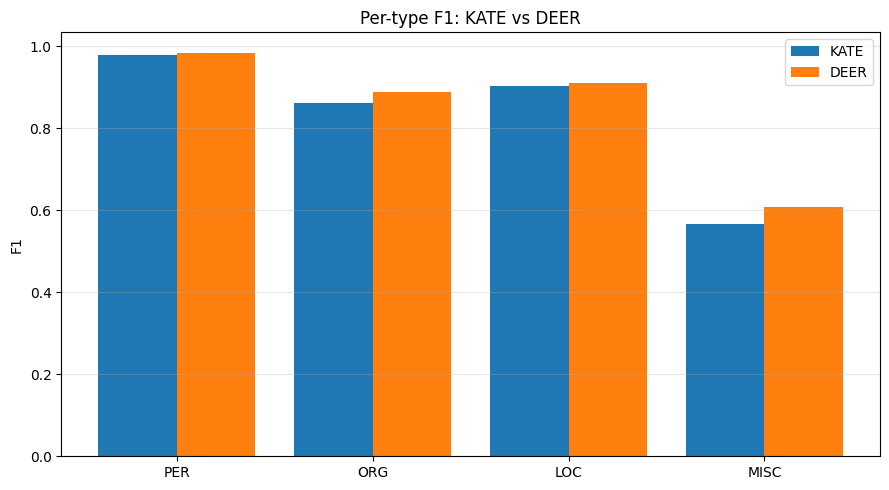

In [12]:
from seqeval.metrics import classification_report

rep = {c: classification_report(*outputs[c][:2], output_dict=True, mode="strict", scheme=IOB2)
       for c in ["kate", "deer"]}
x = np.arange(len(ENTITY_TYPES))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.2, [rep["kate"].get(t, {}).get("f1-score", 0) for t in ENTITY_TYPES], 0.4, label="KATE")
ax.bar(x + 0.2, [rep["deer"].get(t, {}).get("f1-score", 0) for t in ENTITY_TYPES], 0.4, label="DEER")
ax.set_xticks(x, ENTITY_TYPES)
ax.set_ylabel("F1")
ax.set_title("Per-type F1: KATE vs DEER")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

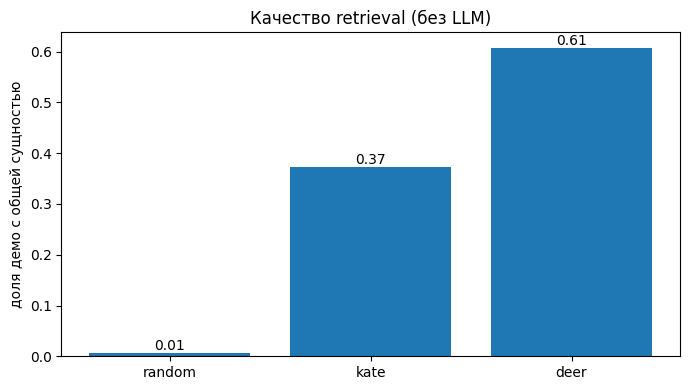

In [13]:
def shared_entity_rate(method):
    rates = []
    for qi, ex in enumerate(test_examples):
        q_ent = set(w for e in ex["ent_list"] for w in e["name"].lower().split())
        if not q_ent:
            continue
        demos = retrieve(ex, test_embs[qi], method)
        if not demos:
            continue
        hit = sum(bool(q_ent & set(w for e in d["ent_list"] for w in e["name"].lower().split())) for d in demos)
        rates.append(hit / len(demos))
    return float(np.mean(rates))


rq = {m: shared_entity_rate(m) for m in ["random", "kate", "deer"]}
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(list(rq), list(rq.values()))
for i, v in enumerate(rq.values()):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom")
ax.set_ylabel("доля демо с общей сущностью")
ax.set_title("Качество retrieval (без LLM)")
plt.tight_layout()
plt.show()

In [14]:
import csv

print(f"{'config':<10}{'P':>8}{'R':>8}{'F1':>8}")
for c, r in results.items():
    print(f"{c:<10}{r['precision']:>8.3f}{r['recall']:>8.3f}{r['f1']:>8.3f}")

with open("results.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["config", "precision", "recall", "f1"])
    for c, r in results.items():
        w.writerow([c, r["precision"], r["recall"], r["f1"]])

config           P       R      F1
zero         0.693   0.729   0.710
random       0.766   0.787   0.776
kate         0.881   0.890   0.885
deer         0.897   0.900   0.899


## Выводы

Четыре способа выбора демо для in-context NER на одной модели qwen-2.5-72b-instruct, 200 тестовых предложений CoNLL-2003, seqeval strict IOB2, один прогон.

| метод | F1 | precision | recall |
|---|---|---|---|
| zero | 0.710 | | |
| random | 0.776 | | |
| kate | 0.885 | 0.881 | 0.890 |
| deer | 0.899 | 0.897 | 0.900 |

Random даёт +0.066 к zero за счёт формата ответа. KATE добавляет +0.100 над random, тут основная прибавка. DEER поверх KATE ещё +0.014, 0.885 -> 0.899, precision 0.881 -> 0.897, recall 0.890 -> 0.900. Разница DEER против KATE маленькая на уровне шума. Тест небольшой, модель и эмбеддер фиксированы, прогон один. Результат на этом прогоне - DEER не хуже KATE, recall чуть выше. На графиках deer и kate рядом и выше random, zero

### F1 к число шотов

Кривая f1 по числу шотов для kate, и deer на подвыборке из 80 элементов

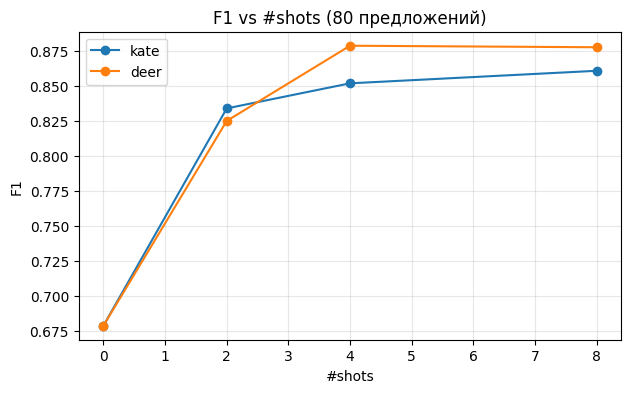

In [15]:
shots = [0, 2, 4, 8]
sub = test_examples[:80]
sub_embs = test_embs[:80]
curve = {"kate": [], "deer": []}
for m in curve:
    for n in shots:
        g, p = [], []
        for qi, ex in enumerate(sub):
            demos = retrieve(ex, sub_embs[qi], m, n=n)
            ents = entities_to_offsets(parse_entities(generate(build_messages(demos, ex["text"]))), ex["tokens"])
            g.append(entities_to_bio(ex["tokens"], ex["ent_list"]))
            p.append(entities_to_bio(ex["tokens"], ents))
        curve[m].append(f1_score(g, p, mode="strict", scheme=IOB2))

plt.figure(figsize=(7, 4))
for m, ys in curve.items():
    plt.plot(shots, ys, marker="o", label=m)
plt.xlabel("#shots")
plt.ylabel("F1")
plt.title("F1 vs #shots (80 предложений)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()